In [1]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import numpy as np
import json
import pymc as pm
from solar_models import build_dynamic_model
import matplotlib.pyplot as plt
import arviz as az
import pytensor

# Disable C++ compilation to stop macOS warning spam. 
pytensor.config.cxx = ""

import warnings
warnings.filterwarnings("ignore")
print(f"NumPy version: {np.__version__}")
print("PyMC imported successfully!")

NumPy version: 1.26.4
PyMC imported successfully!


In [3]:
# Load the fully merged and engineered dataset
df = pd.read_csv('../data/merged/merged_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# Generate 3 pairs of Fourier harmonics for annual seasonality
for k in range(1, 4):
    df[f'sin_k{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[f'cos_k{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365.25)

# Store standardizations for back-calculation later
demand_mean, demand_std = df['demand_mwh_day'].mean(), df['demand_mwh_day'].std()

# Standardize features (Z-scores)
df['demand_scaled'] = (df['demand_mwh_day'] - demand_mean) / demand_std
df['temp_scaled'] = (df['temp_mean_c'] - df['temp_mean_c'].mean()) / df['temp_mean_c'].std()
df['proxy_scaled'] = (df['selfcons_theoretical_mwh'] - df['selfcons_theoretical_mwh'].mean()) / df['selfcons_theoretical_mwh'].std()


In [4]:
# 1. Load the configuration file and the data
with open('experiments_config.json', 'r') as file:
    experiments = json.load(file)

os.makedirs('models', exist_ok=True)
results_dict = {}

In [5]:
# 2. Execute the Pipeline
for config in experiments:
    model_name = config["name"]
    file_path = f"models/trace_{model_name}.nc"
    
    print(f"\n--- Processing: {model_name} ---")
    
    if os.path.exists(file_path):
        print(f"Loading existing trace from {file_path}...")
        trace = az.from_netcdf(file_path)
    else:
        print(f"Building model and running MCMC for {model_name}...")
        
        # Build the model using the imported blueprint and current JSON config
        model = build_dynamic_model(df, config)
        
        with model:
            trace = pm.sample(draws=1000, 
                              tune=1000, 
                              chains=4, 
                              target_accept=0.95, 
                              nuts_sampler="numpyro", 
                              return_inferencedata=True,
                              random_seed=42)
            
            print(f"Saving to {file_path}...")
            az.to_netcdf(trace, file_path)
    
    results_dict[model_name] = trace

print("\nPipeline execution complete!")


--- Processing: v1_baseline ---
Loading existing trace from models/trace_v1_baseline.nc...

--- Processing: v2_strict_solar ---
Loading existing trace from models/trace_v2_strict_solar.nc...

--- Processing: v3_normal_likelihood ---
Loading existing trace from models/trace_v3_normal_likelihood.nc...

Pipeline execution complete!


In [7]:
print("Retroactively computing missing log-likelihoods...")

# Loop through your configurations to calculate the missing data
for config in experiments:
    model_name = config["name"]
    trace = results_dict[model_name]
    
    # Check if the log_likelihood group is missing
    if "log_likelihood" not in trace:
        print(f"Computing for {model_name}...")
        
        # 1. Rebuild the specific model blueprint
        model = build_dynamic_model(df, config)
        
        # 2. Tell PyMC to calculate the pointwise log-likelihood
        with model:
            pm.compute_log_likelihood(trace)
            
        # 3. The Unix File Swap (Bypassing the lock)
        file_path = f"models/trace_{model_name}.nc"
        temp_path = f"models/temp_{model_name}.nc"
        
        print(f"   -> Saving safely to bypass file lock...")
        # Save to a brand new temporary file
        trace.to_netcdf(temp_path)
        
        # Atomically replace the old locked file with the new complete one
        os.replace(temp_path, file_path)

print("\nAll log-likelihoods successfully computed! You are ready to run the comparison.")

Retroactively computing missing log-likelihoods...
Computing for v2_strict_solar...


   -> Saving safely to bypass file lock...
Computing for v3_normal_likelihood...


   -> Saving safely to bypass file lock...

All log-likelihoods successfully computed! You are ready to run the comparison.


Calculating Leave-One-Out Cross-Validation (LOO) for all models...

--- BAYESIAN MODEL LEADERBOARD ---


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
v1_baseline,0,6336.642050,13.668138,0.000000,0.835579,127.333152,0.000000,False,deviance
v2_strict_solar,1,6336.764093,13.723073,0.122042,0.000000,127.315544,0.089157,False,deviance
v3_normal_likelihood,2,6807.232373,13.068935,470.590323,0.164421,143.111109,63.443708,False,deviance


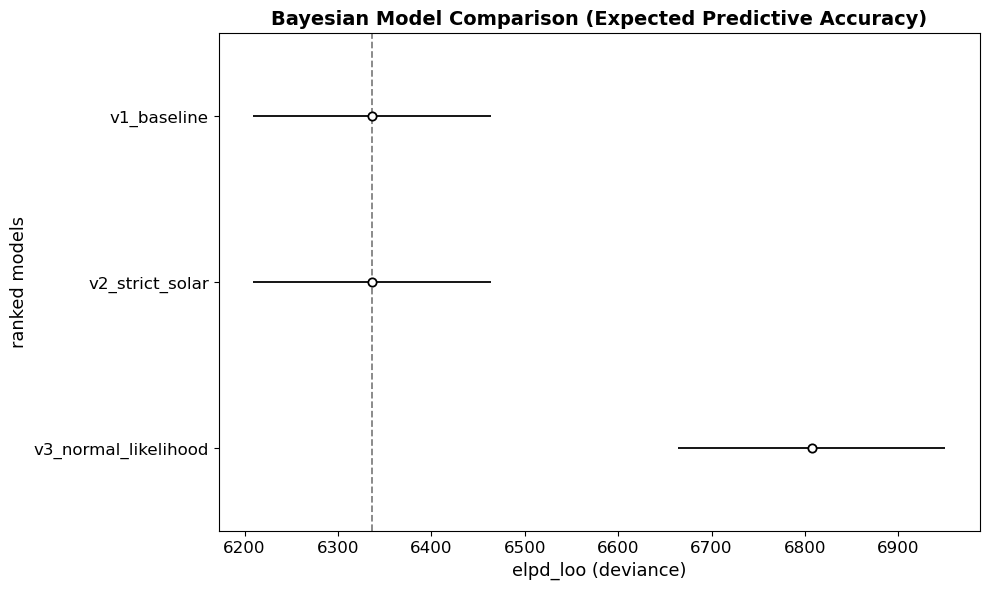

In [8]:
# 1. Compare the models using Leave-One-Out (LOO) cross-validation
print("Calculating Leave-One-Out Cross-Validation (LOO) for all models...")
comparison_df = az.compare(results_dict, ic="loo", scale="deviance")

# 2. Display the mathematical leaderboard
print("\n--- BAYESIAN MODEL LEADERBOARD ---")
display(comparison_df)

# 3. Visualize the comparison
fig, ax = plt.subplots(figsize=(10, 6))
az.plot_compare(comparison_df, ax=ax, textsize=12)
ax.set_title("Bayesian Model Comparison (Expected Predictive Accuracy)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()